[[[  1  39 137]
  [156  98  44]
  [252 239 187]
  [176  18  28]]

 [[255 255 254]
  [143  79  46]
  [226  72 132]
  [188  48 119]]

 [[118  43  32]
  [231 179   5]
  [ 25  16   6]
  [121  67   2]]

 [[163  94   2]
  [149  64   8]
  [ 14  14   4]
  [132 120   2]]]


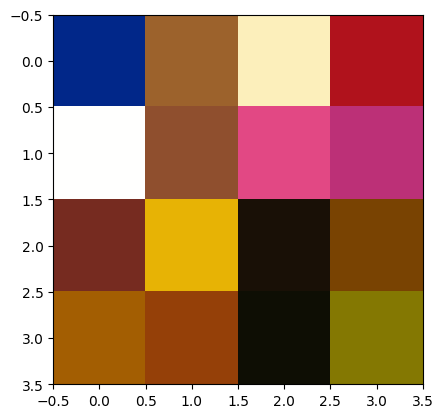

In [9]:
import cv2
from matplotlib import pyplot as plt
import numpy as np

raw_img = cv2.imread(r'E:\work\Code\ColorAnything\examples\000000000009.jpg')
img = cv2.resize(raw_img, (4, 4), interpolation=cv2.INTER_CUBIC)
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# pred = net.infer_image(img, input_size=1036)
plt.imshow(rgb) 
lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
# print(lab)
print(rgb)
# filename = '\\000000581767.jpg'
# cv2.imwrite(r'E:\work\Code\ColorAnything\example_output' + filename, pred_bgr)

array([[[  0, 139, 255]]], dtype=uint8)

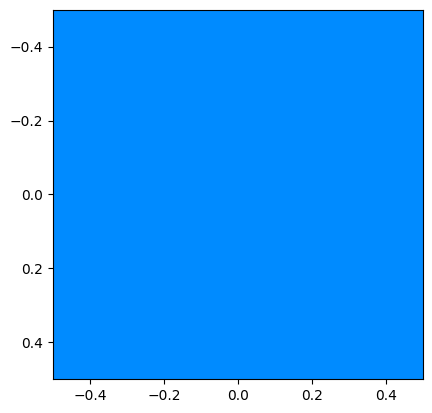

In [ ]:
testimg = np.ndarray([1, 1, 3], dtype=np.uint8)
testimg[0, 0] = [128, 128, 0]
testimg = cv2.cvtColor(testimg, cv2.COLOR_LAB2RGB)
plt.imshow(testimg)
testimg

array([[[136, 208, 195]]], dtype=uint8)

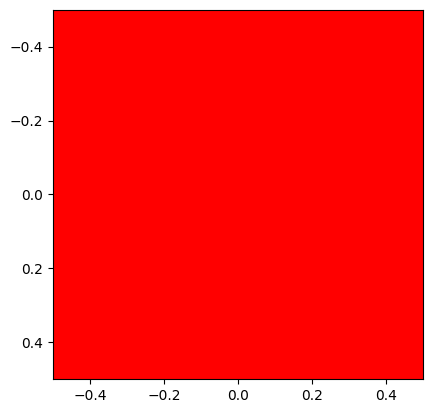

In [18]:
testimg = np.ndarray([1, 1, 3], dtype=np.uint8)
testimg[0, 0] = [255, 0, 0]
plt.imshow(testimg)
testimg = cv2.cvtColor(testimg, cv2.COLOR_RGB2LAB)
testimg

In [17]:
cv2.COLOR_RGB2LAB

45

In [6]:
import cv2
from matplotlib import pyplot as plt
import numpy as np

raw_img = cv2.imread(r'E:\work\Code\ColorAnything\examples\000000000009.jpg')
raw_img = cv2.resize(raw_img, (4, 4), interpolation=cv2.INTER_CUBIC)
rgb = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
# pred = net.infer_image(img, input_size=1036)
# plt.imshow(rgb) 
lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
# print(lab)
grey = lab[:, :, 0]
# plt.imshow(grey, cmap='grey')
# plt.imshow(rgb)
lab[:, :, (1, 2)]
# filename = '\\000000581767.jpg'
# cv2.imwrite(r'E:\work\Code\ColorAnything\example_output' + filename, pred_bgr)

array([[[159,  71],
        [147, 167],
        [125, 155],
        [187, 167]],

       [[128, 128],
        [152, 159],
        [192, 128],
        [189, 121]],

       [[160, 152],
        [134, 206],
        [132, 133],
        [147, 172]],

       [[151, 183],
        [161, 174],
        [128, 132],
        [122, 183]]], dtype=uint8)

In [1]:
import torch
from model.ColorAnything import ColorAnything
import numpy as np

In [2]:
net = ColorAnything(mode='lab')
net.to('cuda')
net.load_state_dict(torch.load('./checkpoints/lab/10.pth'))

Backbone does not define embed_dims, using [embed_dim] * n_blocks=[384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384] instead
Backbone does not define input_pad_size, using patch_size=16 instead
c:\ProgramData\miniconda3\envs\rgb\lib\site-packages\torch\functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4324.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


<All keys matched successfully>

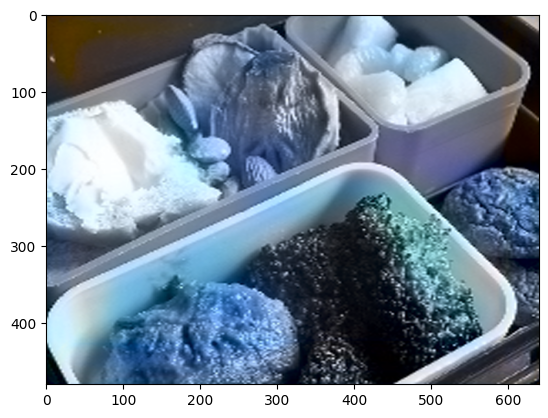

In [3]:
import cv2
from matplotlib import pyplot as plt
raw_img = cv2.imread(r'E:\work\Code\ColorAnything\examples\000000000009.jpg')
plt.imshow(net.infer_image(raw_img))

In [ ]:
grey, (h, w) = net.image2tensor(raw_img)
print(grey.shape, grey)

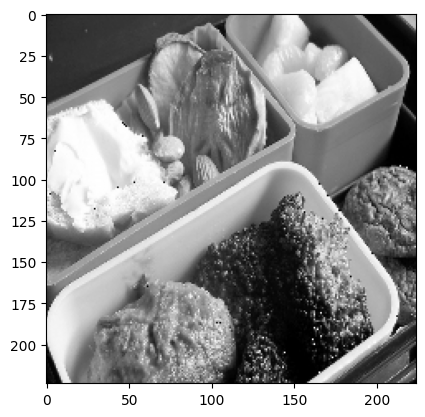

In [5]:
from matplotlib import pyplot as plt
plt.imshow((torch.squeeze(grey, axis=0)*255).cpu().numpy().astype('uint8'), cmap='grey')

In [10]:
y = net(grey.unsqueeze(dim=0))
y

tensor([[[[0.4188, 0.5174, 0.5185,  ..., 0.5248, 0.5099, 0.4530],
          [0.4762, 0.4990, 0.5045,  ..., 0.5019, 0.5003, 0.4992],
          [0.4966, 0.4931, 0.5116,  ..., 0.5257, 0.5128, 0.4958],
          ...,
          [0.5180, 0.5045, 0.5080,  ..., 0.4940, 0.5001, 0.5272],
          [0.4997, 0.4994, 0.5115,  ..., 0.4947, 0.5062, 0.5145],
          [0.4599, 0.5101, 0.5372,  ..., 0.5070, 0.5156, 0.4620]],

         [[0.4029, 0.4531, 0.4464,  ..., 0.5064, 0.5026, 0.4761],
          [0.4387, 0.4339, 0.4179,  ..., 0.4962, 0.4798, 0.4836],
          [0.4385, 0.4188, 0.4331,  ..., 0.5143, 0.4975, 0.4943],
          ...,
          [0.5730, 0.5755, 0.5713,  ..., 0.4961, 0.4944, 0.5153],
          [0.5896, 0.5860, 0.5896,  ..., 0.5018, 0.5274, 0.5165],
          [0.5143, 0.5660, 0.5901,  ..., 0.5197, 0.5273, 0.4664]]]],
       device='cuda:0', grad_fn=<ConvolutionBackward0>)

In [16]:
pred = np.concatenate((grey.cpu().detach().numpy(), y.squeeze(axis=0).cpu().detach().numpy()), axis=0)
pred

array([[[0.14501679, 0.14339553, 0.14351729, ..., 0.7066031 ,
         0.7011733 , 0.683203  ],
        [0.13532825, 0.14311402, 0.1482614 , ..., 0.70734566,
         0.7161763 , 0.6891007 ],
        [0.14453982, 0.14822629, 0.16237438, ..., 0.7257366 ,
         0.7013887 , 0.70167685],
        ...,
        [0.00749994, 0.03575988, 0.05656869, ..., 0.32891375,
         0.65651476, 0.17615248],
        [0.00794152, 0.01888927, 0.05479806, ..., 0.25703794,
         0.10332835, 0.02832245],
        [0.00333337, 0.01016928, 0.02644516, ..., 0.07158273,
         0.02952429, 0.00887448]],

       [[0.4188085 , 0.51740324, 0.51845145, ..., 0.52481073,
         0.5098926 , 0.45302293],
        [0.47621623, 0.49898365, 0.5045477 , ..., 0.5018568 ,
         0.5003213 , 0.4992322 ],
        [0.49661514, 0.49311402, 0.51161045, ..., 0.5256944 ,
         0.5128362 , 0.49579474],
        ...,
        [0.51800597, 0.5045042 , 0.5079802 , ..., 0.4940377 ,
         0.50005996, 0.5271729 ],
        [0.4

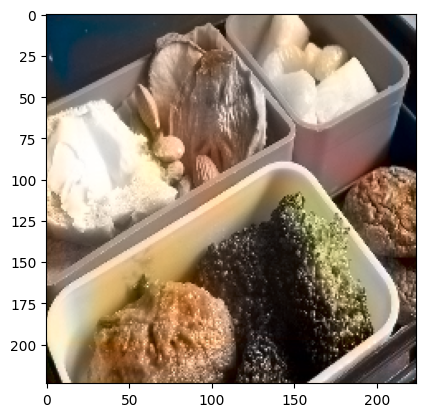

In [27]:
plt.imshow(cv2.cvtColor((np.transpose(pred, (1, 2, 0)).clip(0.0, 1.0)*255).astype('uint8'), cv2.COLOR_Lab2RGB))

In [17]:
from time import sleep
for i in range(4, 41):
    cv2.imwrite(f'{i}.png', net.infer_image(raw_img, input_size=16 * i))


In [25]:
a = torch.randint(0, 100, (1, 1, 64, 64), dtype=torch.float32) / 100
y = net(a)
torch.max(y), torch.min(y), y

(tensor(0.7130, grad_fn=<MaxBackward1>),
 tensor(0.3772, grad_fn=<MinBackward1>),
 tensor([[[[0.3879, 0.5219, 0.5529,  ..., 0.5264, 0.5066, 0.4357],
           [0.4540, 0.5587, 0.5968,  ..., 0.5899, 0.5547, 0.4878],
           [0.4874, 0.5706, 0.6104,  ..., 0.6213, 0.5838, 0.4837],
           ...,
           [0.5128, 0.5707, 0.6092,  ..., 0.4597, 0.4771, 0.5007],
           [0.4603, 0.5345, 0.5929,  ..., 0.4682, 0.4965, 0.4802],
           [0.3772, 0.4517, 0.5030,  ..., 0.4494, 0.4646, 0.4106]],
 
          [[0.3953, 0.5032, 0.5354,  ..., 0.5283, 0.5032, 0.4633],
           [0.4688, 0.5380, 0.5634,  ..., 0.5904, 0.5394, 0.4718],
           [0.4906, 0.5505, 0.5878,  ..., 0.6412, 0.5887, 0.4863],
           ...,
           [0.5220, 0.5626, 0.6206,  ..., 0.4707, 0.4937, 0.5195],
           [0.4648, 0.5229, 0.5796,  ..., 0.4836, 0.4967, 0.4773],
           [0.3829, 0.4429, 0.4816,  ..., 0.4820, 0.4536, 0.3981]]]],
        grad_fn=<ConvolutionBackward0>))

(tensor(0.1766, grad_fn=<MaxBackward1>),
 tensor(-0.3063, grad_fn=<MinBackward1>))

In [3]:
from datetime import datetime
datetime.now().strftime("%m%d-%H%M%S")

'0401-163358'